In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F 
from sklearn import datasets

In [78]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, cond_features=None, bias=True):
        super().__init__(in_features, out_features, bias=bias)
        self.cond = None
        if cond_features is not None:
            self.cond = nn.Linear(cond_features, out_features, bias=False)
        self.register_buffer("mask", torch.ones(out_features, in_features))

    def set_mask(self, mask):
        self.mask.data.copy_(mask)

    def forward(self, x, y=None):
        z = F.linear(x, self.weight * self.mask, self.bias)

        # unconditional path
        if self.cond is None:
            return z

        # conditional path
        if y is None:
            raise ValueError("MaskedLinear is conditional but y=None was passed.")
        return z + self.cond(y)


In [79]:
class MADE(nn.Module):
    def __init__(self, D, cond_size=None, hidden_sizes=(64, 64), natural_ordering=True):
        super().__init__()
        self.D = D
        self.cond_size = cond_size
        self.natural_ordering = natural_ordering

        sizes = [D, *hidden_sizes, 2*D]
        self.layers = nn.ModuleList([
            MaskedLinear(sizes[i], sizes[i+1], cond_features=cond_size)
            for i in range(len(sizes) - 1)
        ])
        self.acts = nn.ModuleList([nn.ReLU() for _ in range(len(sizes)-2)])

        self.create_masks()

    def create_masks(self):
        D = self.D

        if self.natural_ordering:
            input_degrees = torch.arange(1, D+1)
        else:
            input_degrees = torch.randperm(D) + 1

        degrees = [input_degrees]
        for layer in self.layers[:-1]:
            deg = torch.randint(1, D, (layer.out_features,))
            degrees.append(deg)

        output_degrees = torch.arange(1, D+1).repeat(2)
        degrees.append(output_degrees)


        # masks
        for l, layer in enumerate(self.layers):
            d_in = degrees[l]
            d_out = degrees[l+1]
            if l < len(self.layers)-1:
                mask = (d_out[:,None] >= d_in[None, :]).float()
            else:
                mask = (d_out[:,None] > d_in[None, :]).float()

            layer.set_mask(mask)

    def forward(self, x, y=None):
        h = x
        for i, layer in enumerate(self.layers[:-1]):
            h = self.acts[i](layer(h, y))
        out = self.layers[-1](h, y)
        mu, log_sigma = out.chunk(2, dim=-1)
        return mu , log_sigma
            

In [80]:
class MAFBlock(nn.Module):
    def __init__(self, D, cond_size=None, hidden_sizes=(64,64), clamp=5.0):
        super().__init__()
        self.D = D
        self.cond_size = cond_size
        self.net = MADE(D, cond_size=cond_size, hidden_sizes=hidden_sizes)
        self.clamp = clamp

    def forward(self, x, y = None):
        # x -> z (parallel)
        mu, log_sigma = self.net(x, y)
        log_sigma = torch.clamp(log_sigma, -self.clamp, self.clamp)
        z = (x - mu) * torch.exp(-log_sigma)
        logdet = -log_sigma.sum(dim=-1)
        return z, logdet

    @torch.no_grad()
    def reverse(self, z, y=None):
        # z -> x (sequential)
        x = torch.zeros_like(z)
        for i in range(self.D):
            mu, log_sigma = self.net(x, y)
            log_sigma = torch.clamp(log_sigma, -self.clamp, self.clamp)
            x[:, i] = z[:, i] * torch.exp(log_sigma[:, i]) + mu[:, i]
        return x


In [81]:
class Permute(nn.Module):
    def __init__(self, perm):
        super().__init__()
        self.register_buffer("perm", torch.tensor(perm, dtype=torch.long))
        inv = torch.empty_like(self.perm)
        inv[self.perm] = torch.arange(len(self.perm))
        self.register_buffer("inv_perm", inv)

    def forward(self, x, y=None):
        return x[:, self.perm], torch.zeros(x.size(0), device=x.device)

    @torch.no_grad()
    def reverse(self, z, y=None):
        return z[:, self.inv_perm]


In [82]:
class MAF(nn.Module):
    def __init__(self, input_size, condition_size = None, hidden_sizes=(64,64), blocks=5):
        super().__init__()
        self.input_size = input_size
        self.condition_size = condition_size

        self.blocks = nn.ModuleList()
        for _ in range(blocks):
            self.blocks.append(
                MAFBlock(D=input_size, cond_size=condition_size, hidden_sizes=hidden_sizes)
            )
            self.blocks.append(Permute(list(reversed(range(input_size)))))

    def forward(self, x, y=None):
        log_det_jacob = torch.zeros(x.size(0), device=x.device)
        h = x
        for layer in self.blocks:
            h, ld = layer(h, y)
            log_det_jacob += ld
        return h, log_det_jacob

    def reverse(self, z, y=None):
        h = z
        for layer in reversed(self.blocks):
            h = layer.reverse(h, y)
        return h

    def sample(self, n_samples, y=None):
        device = y.device if y is not None else next(self.parameters()).device
        z = torch.randn(n_samples, self.input_size, device=device)
        return self.reverse(z, y)


In [83]:
def get_moons_unconditional(n_samples=1000, noise=0.1):
    X, _ = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X

def get_moons_conditional(n_samples=1000, noise=0.1):
    X, y = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.nn.functional.one_hot(
        torch.tensor(y), num_classes=2
    ).float()
    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X, y

In [84]:
def train_inn(model, dataloader, n_samples=1000, epochs=100, lr = 0.001):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    loss_values = []

    for _ in range(epochs):
        total_training_loss = 0
        for batch in dataloader:
            x=batch[0]
            if model.condition_size is not None:
                y = batch[1]
                z, log_det_jacob = model(x, y)
            else:
                z, log_det_jacob = model(x)
            loss = torch.mean(1/2 * x.shape[1] * torch.log(torch.tensor(2*torch.pi)) + 1/2 * torch.sum(z ** 2, dim=1) - log_det_jacob)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_training_loss += loss.item()
        loss_values.append(total_training_loss)

    return model, loss_values    

In [85]:
def plot_lc(losses):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.show()

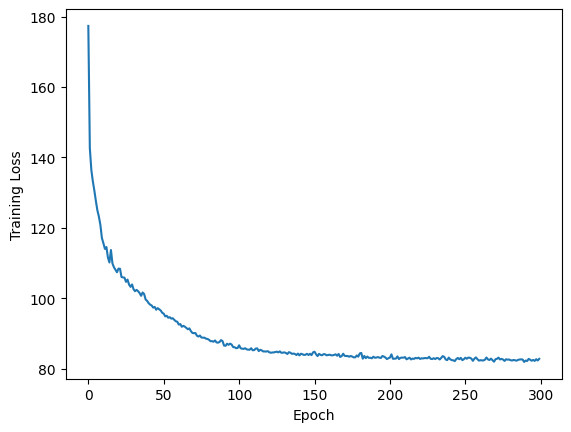

In [93]:
uncond_loader, X_uncond = get_moons_unconditional(5000)
maf = MAF(input_size=2, hidden_sizes=(64,64), blocks=5)
maf, maf_losses = train_inn(maf, uncond_loader, epochs=300, lr=1e-4)
plot_lc(maf_losses)
samples = maf.sample(2000).detach().numpy()

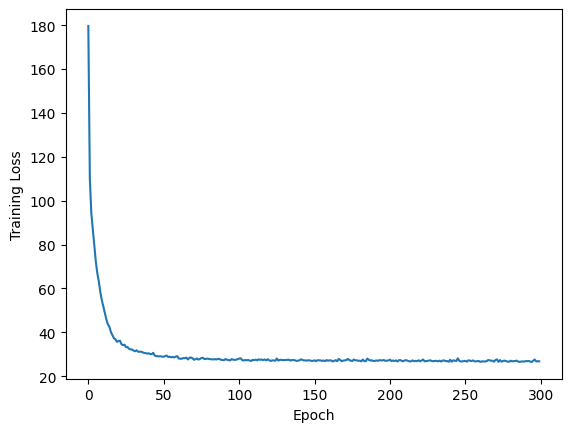

In [87]:
cond_loader, X, y = get_moons_conditional(n_samples=5000, noise=0.1)

cmaf = MAF(input_size=2, condition_size=2, hidden_sizes=(64,64), blocks=5)
cmaf, cmaf_losses = train_inn(cmaf, cond_loader, epochs=300, lr=1e-4)

plot_lc(cmaf_losses)

In [88]:
n = 2000
y0 = torch.zeros(n, 2)
y0[:, 0] = 1.0

samples0 = cmaf.sample(n, y=y0).detach().cpu().numpy()

y1 = torch.zeros(n, 2)
y1[:, 1] = 1.0

samples1 = cmaf.sample(n, y=y1).detach().cpu().numpy()

Text(0, 0.5, '$\\hat{X}_2$')

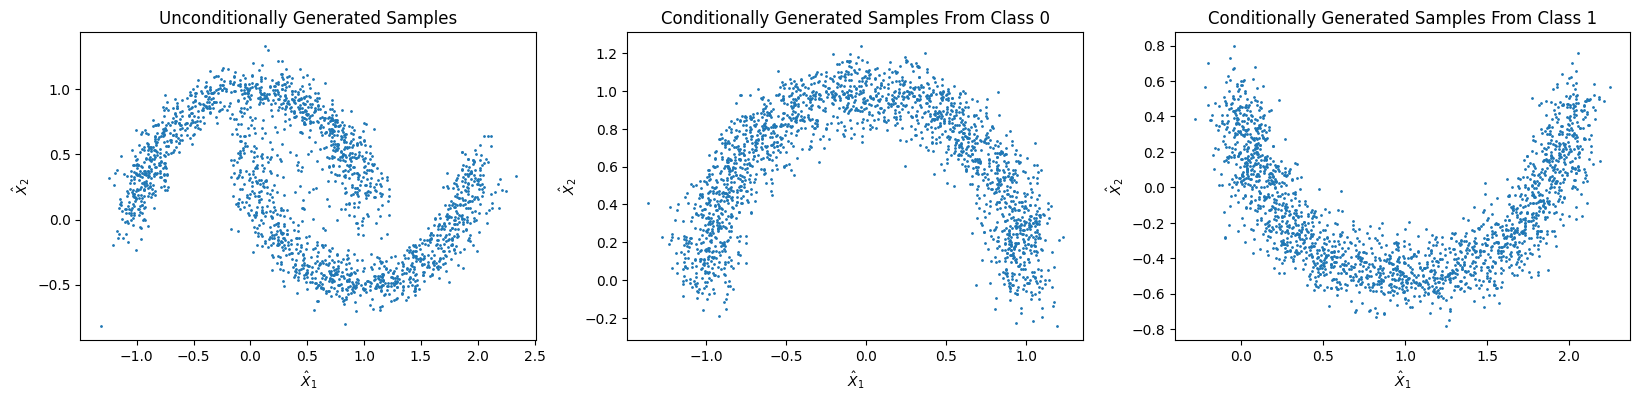

In [101]:
fig, axs = plt.subplots(1,3, figsize=(20,4))
axs[0].set_title("Unconditionally Generated Samples")
axs[0].scatter(samples[:,0], samples[:,1], s=1,label="Generated Data")
axs[0].set_xlabel(r"$\hat{X}_1$")
axs[0].set_ylabel(r"$\hat{X}_2$")

axs[1].set_title("Conditionally Generated Samples From Class 0")
axs[1].scatter(samples0[:,0], samples0[:,1], s=1,label="Generated Data")
axs[1].set_xlabel(r"$\hat{X}_1$")
axs[1].set_ylabel(r"$\hat{X}_2$")

axs[2].set_title("Conditionally Generated Samples From Class 1")
axs[2].scatter(samples1[:,0], samples1[:,1], s=1,label="Generated Data")
axs[2].set_xlabel(r"$\hat{X}_1$")
axs[2].set_ylabel(r"$\hat{X}_2$")

In [97]:
uncond_test_loader, X_test_uncond = get_moons_unconditional(n_samples=5000, noise=0.1)
cond_test_loader, X_test_cond, y_test_cond = get_moons_conditional(n_samples=5000, noise=0.1)


In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def eval_nll(model, dataloader, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll = 0.0
    total_n = 0

    for batch in dataloader:
        x = batch[0].to(device)
        D = x.shape[1]
        const = 0.5 * D * torch.log(torch.tensor(2 * torch.pi, device=device))

        if getattr(model, "condition_size", None) is not None:
            y = batch[1].to(device)
            z, log_det = model(x, y)
        else:
            z, log_det = model(x)

        nll = const + 0.5 * torch.sum(z**2, dim=1) - log_det
        total_nll += nll.sum().item()
        total_n += x.size(0)

    return total_nll / total_n

def _rbf_kernel(x, y, sigma):
    x_norm = (x**2).sum(dim=1, keepdim=True)
    y_norm = (y**2).sum(dim=1, keepdim=True).t()
    dist2 = x_norm + y_norm - 2.0 * x @ y.t()
    return torch.exp(-dist2 / (2.0 * sigma**2))

@torch.no_grad()
def mmd_rbf(x, y, sigma=None, max_pts=1000):
    x = x.detach()
    y = y.detach()

    if sigma is None:
        z = torch.cat([x, y], dim=0)
        if z.size(0) > max_pts:
            idx = torch.randperm(z.size(0))[:max_pts]
            z = z[idx]
        z_norm = (z**2).sum(dim=1, keepdim=True)
        dist2 = z_norm + z_norm.t() - 2.0 * z @ z.t()
        dist2 = dist2[torch.triu(torch.ones_like(dist2), diagonal=1) == 1]
        median_dist = torch.sqrt(torch.median(dist2).clamp(min=1e-12))
        sigma = median_dist.item()

    Kxx = _rbf_kernel(x, x, sigma)
    Kyy = _rbf_kernel(y, y, sigma)
    Kxy = _rbf_kernel(x, y, sigma)

    n = x.size(0)
    m = y.size(0)
    if n > 1:
        Kxx = Kxx - torch.diag(torch.diag(Kxx))
        mmd_xx = Kxx.sum() / (n * (n - 1))
    else:
        mmd_xx = 0.0

    if m > 1:
        Kyy = Kyy - torch.diag(torch.diag(Kyy))
        mmd_yy = Kyy.sum() / (m * (m - 1))
    else:
        mmd_yy = 0.0

    mmd_xy = Kxy.mean()
    return float((mmd_xx + mmd_yy - 2.0 * mmd_xy).item())

@torch.no_grad()
def sampling_speed(model, sample_fn, n_samples=2000, n_repeats=20, warmup=5):
    model.eval()
    for _ in range(warmup):
        _ = sample_fn(n_samples)

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        _ = sample_fn(n_samples)
    t1 = time.perf_counter()

    total = n_samples * n_repeats
    return total / (t1 - t0)


In [99]:
# --- fresh evaluation sets ---
uncond_test_loader, X_test_uncond = get_moons_unconditional(n_samples=5000, noise=0.1)
cond_test_loader, X_test_cond, y_test_cond = get_moons_conditional(n_samples=5000, noise=0.1)

device = next(maf.parameters()).device

def sample_maf_uncond(n):
    return maf.sample(n).to(device)

def sample_maf_cond_mix(n):
    n0 = n // 2
    n1 = n - n0
    y0 = torch.zeros(n0, 2, device=device); y0[:,0] = 1.0
    y1 = torch.zeros(n1, 2, device=device); y1[:,1] = 1.0
    s0 = cmaf.sample(n0, y=y0).to(device)
    s1 = cmaf.sample(n1, y=y1).to(device)
    return torch.cat([s0, s1], dim=0)

rows = []

# Unconditional
nll = eval_nll(maf, uncond_test_loader, device=device)
gen = sample_maf_uncond(2000)
mmd = mmd_rbf(gen, X_test_uncond.to(device)[:2000])
sps = sampling_speed(maf, sample_maf_uncond, n_samples=2000)
rows.append({
    "Model": "MAF (uncond)",
    "Params": count_params(maf),
    "Test NLL ↓": nll,
    "MMD² ↓": mmd,
    "Sampling (samples/s) ↑": sps
})

# Conditional (mixture)
nll = eval_nll(cmaf, cond_test_loader, device=device)
gen = sample_maf_cond_mix(2000)
mmd = mmd_rbf(gen, X_test_cond.to(device)[:2000])
sps = sampling_speed(cmaf, sample_maf_cond_mix, n_samples=2000)
rows.append({
    "Model": "MAF (cond, mix)",
    "Params": count_params(cmaf),
    "Test NLL ↓": nll,
    "MMD² ↓": mmd,
    "Sampling (samples/s) ↑": sps
})

maf_df = pd.DataFrame(rows)
maf_df


,Model,Params,Test NLL ↓,MMD² ↓,Sampling (samples/s) ↑
0,MAF (uncond),23060,1.084179,-0.000353,440734.439858
1,"MAF (cond, mix)",24380,0.322131,0.000114,217420.845198
